# Data Download & Weekly RV

Calls `src/data.py` functions. No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
from src.data import (
    download_prices, compute_log_returns, compute_weekly_rv,
    make_target, make_splits, download_tbill_rates
)

## Price Download & Universe Construction

In [2]:
prices = download_prices()
print(f"\nShape: {prices.shape}  ({prices.shape[1]} stocks × {prices.shape[0]} trading days)")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")

Fetching S&P 500 constituent list from Wikipedia...
Candidate universe: 50 tickers
After coverage filter (≥ 95%): 50 tickers
Fetching sector assignments for 50 tickers...
Saved: prices.parquet (50 stocks × 2765 days), tickers.json, sector_history.json → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\raw/

Shape: (2765, 50)  (50 stocks × 2765 trading days)
Date range: 2015-01-02 → 2025-12-30


In [3]:
# Verify: no all-NaN columns survived the coverage filter
all_nan_cols = prices.columns[prices.isna().all()].tolist()
assert len(all_nan_cols) == 0, f"All-NaN columns found: {all_nan_cols}"
print(f"No All-NaN columns")

# Coverage stats
coverage = prices.notna().mean()
print(f"\nCoverage (non-NaN fraction):")
print(f"  Min : {coverage.min():.3f}  ({coverage.idxmin()})")
print(f"  Mean: {coverage.mean():.3f}")
print(f"  Max : {coverage.max():.3f}")

No All-NaN columns

Coverage (non-NaN fraction):
  Min : 1.000  (A)
  Mean: 1.000
  Max : 1.000


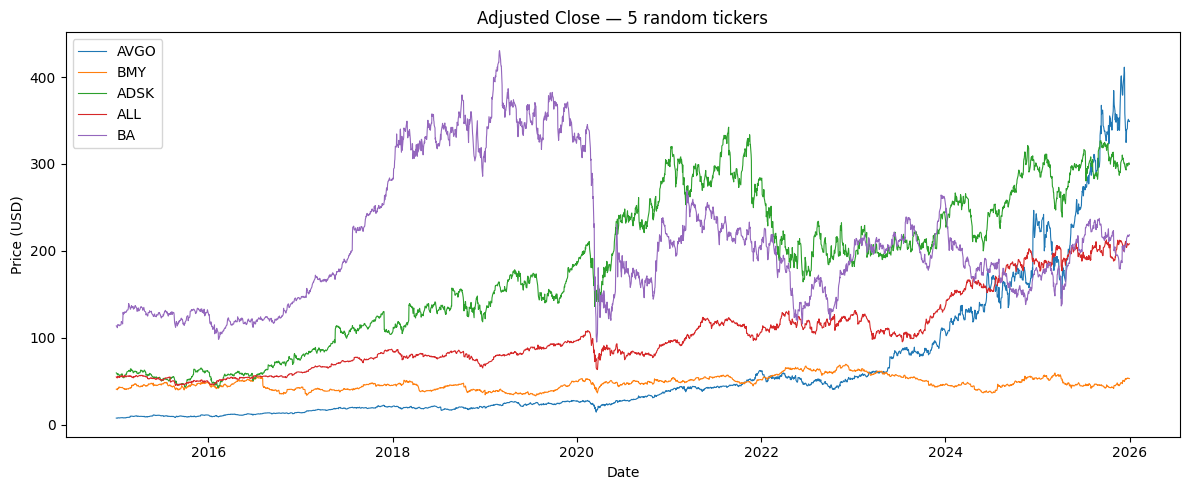

In [4]:
import matplotlib.pyplot as plt
import json, pathlib

# Plot 5 random stock price series
import numpy as np
rng = np.random.default_rng(config.RANDOM_SEED)
sample_tickers = rng.choice(prices.columns.tolist(), size=5, replace=False).tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for t in sample_tickers:
    ax.plot(prices.index, prices[t], label=t, linewidth=0.8)
ax.set_title("Adjusted Close — 5 random tickers")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Spot-check sector_history.json
raw_dir = pathlib.Path("..") / config.DATA_RAW_DIR
with open(raw_dir / "sector_history.json") as f:
    sector_history = json.load(f)

example_ticker = sample_tickers[0]
if example_ticker in sector_history:
    print(f"{example_ticker} sector by year:")
    for yr, sec in sector_history[example_ticker].items():
        print(f"  {yr}: {sec}")
else:
    print("Not in universe")

AVGO sector by year:
  2015: Technology
  2016: Technology
  2017: Technology
  2018: Technology
  2019: Technology
  2020: Technology
  2021: Technology
  2022: Technology
  2023: Technology
  2024: Technology
  2025: Technology


## Log Returns

> **Not yet implemented.** Run after log returns code is written.

In [6]:
log_returns = compute_log_returns(prices)

NotImplementedError: 

## Weekly Realized Volatility

> **Not yet implemented.** Run after weekly RV code is written.

In [ ]:
weekly_rv = compute_weekly_rv(log_returns)

## Target Construction & Lookahead Audit

> **Not yet implemented.** Run after target construction code is written.

In [ ]:
target = make_target(weekly_rv)

## Train / Val / Test Split

> **Not yet implemented.** Run after split code is written.

In [ ]:
splits = make_splits(weekly_rv.index)
print(splits["split"].value_counts().sort_index())